# Pharmaceutical Adherence Analysis — Tutorial

A walkthrough of the `pharma_adherence` package: data cleaning, patient profiling, and ML models for medication adherence.

## 1. Environment Setup

In [1]:
# Install the package in editable mode so any source changes take effect without reinstalling
import importlib.util
import shutil
import subprocess
import sys

install_cmd = [sys.executable, '-m', 'pip', 'install', '-e', '.', '-q']
if importlib.util.find_spec('pip') is None:
    uv = shutil.which('uv')
    if uv is None:
        raise RuntimeError('pip is not installed in this environment and uv is not on PATH.')
    install_cmd = [uv, 'pip', 'install', '--python', sys.executable, '-e', '.', '-q']

result = subprocess.run(install_cmd, check=True)
result


CompletedProcess(args=['/Users/macbook/.local/bin/uv', 'pip', 'install', '--python', '/Users/macbook/Documents/Repos/cdd209-final-template/.venv/bin/python3', '-e', '.', '-q'], returncode=0)

In [2]:
# Activate the inline backend so plots render directly in the notebook
%matplotlib inline

# Standard data and plotting libraries
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Turn off interactive mode so matplotlib never auto-draws during figure construction;
# this prevents recursive draw callbacks in Python 3.14 + matplotlib 3.10
plt.ioff()

# Patch Path.__deepcopy__ to fix infinite recursion in Python 3.14 + matplotlib 3.10.
# The original implementation calls copy.deepcopy(super(), memo) which loops forever
# in Python 3.14 due to changed super() proxy deepcopy behavior.
import copy as _copy
import matplotlib.path as _mpath
def _path_deepcopy_fixed(self, memo):
    cls = type(self)
    result = object.__new__(cls)
    memo[id(self)] = result
    result.__dict__.update(_copy.deepcopy(self.__dict__, memo))
    result._readonly = False
    return result
_mpath.Path.__deepcopy__ = _path_deepcopy_fixed

# Use IPython's display() to show figures explicitly instead of plt.show()
from IPython.display import display

# Import the two main classes from our package
from pharma_adherence import PharmaDataset, ModelTrainer
print('Imports successful!')

Imports successful!


## 2. Load and Clean Data

Raw records have messy dates, dollar signs, duplicates, and out-of-range values. `.clean()` handles all of it.

In [3]:
# Load the medium raw dataset (543 rows) for a good balance of speed and sample size
dataset = PharmaDataset('data/raw/prescriptions_med_raw.csv')
# Keep a snapshot of the raw data to compare against the cleaned version
raw_df = dataset.get_df().copy()
print(f'Shape (raw): {raw_df.shape}')
raw_df.head()

Shape (raw): (542, 14)


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60,60,0.0,34,f,94720.0,D123,walgreens pharmacy,19.73,0,0.57
1,P001,Jan 26 2025,PANTOPRAZOLE,60,120,NaN,34,f,94720.0,D208,csv pharmacy,9,1,0.78
2,P001,Mar 02 2025,AMLODIPINE 5MG,30days,30,NaN,34,f,94720.0,D217,Walgreens,12.6,0,0.65
3,P001,2025-04-04,Metformin HCl,90 days,90,3.0,34,f,94720.0,D159,CSV #13239,$16.55,0,0.72
4,P002,12/30/2024,Albuterol 180mcg,90 days,30,NaN,40,F,90210.0,D197,Walgreens #83887,17.18,0,0.61


In [4]:
# Run the full cleaning pipeline: standardize columns, parse dates, fix types, drop bad rows
dataset.clean()
# Retrieve the cleaned DataFrame for downstream use
df = dataset.get_df()
print(f'Shape (cleaned): {df.shape}  |  Rows dropped: {raw_df.shape[0] - df.shape[0]}')
df.head()

Shape (cleaned): (542, 14)  |  Rows dropped: 0


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60.0,60.0,0.0,34.0,female,94720.0,D123,walgreens,19.73,0.0,0.57
1,P001,2025-01-26,pantoprazole,60.0,120.0,NaN,34.0,female,94720.0,D208,csv,9.00,1.0,0.78
2,P001,2025-03-02,amlodipine,30.0,30.0,NaN,34.0,female,94720.0,D217,walgreens,12.60,0.0,0.65
3,P001,2025-04-04,metformin,90.0,90.0,3.0,34.0,female,94720.0,D159,csv,16.55,0.0,0.72
4,P002,2024-12-30,albuterol,90.0,30.0,NaN,40.0,female,90210.0,D197,walgreens,17.18,0.0,0.61


In [5]:
# Persist the cleaned data to disk so we can reload it without re-running cleaning
dataset.save('data/processed/prescriptions_med_cleaned.csv')
print('Saved cleaned data.')

Saved cleaned data.


## 3. Exploratory Data Analysis

In [6]:
# Show summary statistics (count, mean, std, min/max) for every numeric column
df.describe().round(2)

,fill_date,days_supply,quantity_dispensed,refill_number,patient_age,copay_amount,adherence_flag,proportion_days_covered
count,542,542.00,542.00,176.00,542.00,542.00,542.00,542.00
mean,2025-02-14 15:05:58.671586,76.88,74.67,1.60,54.63,14.72,0.25,0.67
min,2024-12-27 00:00:00,30.00,30.00,0.00,20.00,5.00,0.00,0.39
25%,2025-01-06 00:00:00,60.00,37.50,1.00,40.00,9.95,0.00,0.59
50%,2025-02-03 00:00:00,90.00,75.00,1.00,53.00,14.90,0.00,0.67
75%,2025-03-06 00:00:00,120.00,90.00,2.25,69.00,19.00,0.00,0.75
max,2025-05-06 00:00:00,120.00,120.00,4.00,85.00,24.95,1.00,0.95
std,NaN,33.42,33.32,1.21,18.29,5.62,0.43,0.11


In [7]:
# Count missing values per column; only columns with at least one NaN are shown
missing = df.isnull().sum()
missing[missing > 0]

refill_number    366
zip_code         164
dtype: int64

### PDC Distribution

PDC (Proportion Days Covered) is our adherence measure. Values >= 0.75 are considered adherent.

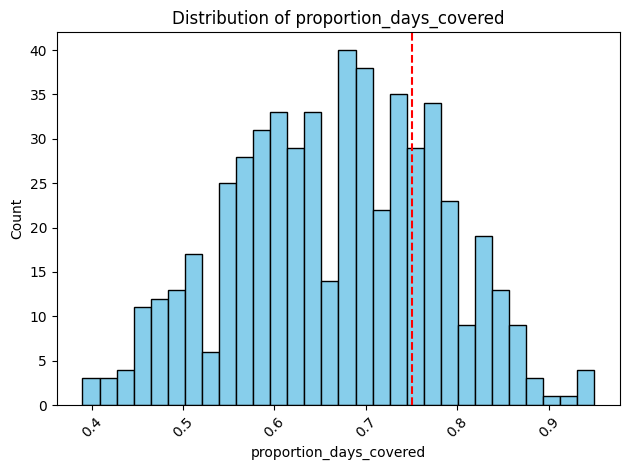

In [8]:
# Plot the PDC histogram; dataset.hist() returns a Figure with axes already configured
fig = dataset.hist('proportion_days_covered')
# Get the axes from the figure to add extra elements
ax = fig.axes[0]
# Overlay a vertical red dashed line at 0.75, the standard clinical adherence threshold
ax.axvline(0.75, color='red', linestyle='--', label='Adherence threshold (0.75)')
# Add a legend to label the threshold line
# ax.legend()
# Tighten spacing so axis labels are not clipped
fig.tight_layout()
# Display via IPython and close immediately so flush_figures does not redisplay it
display(fig)
plt.close(fig)

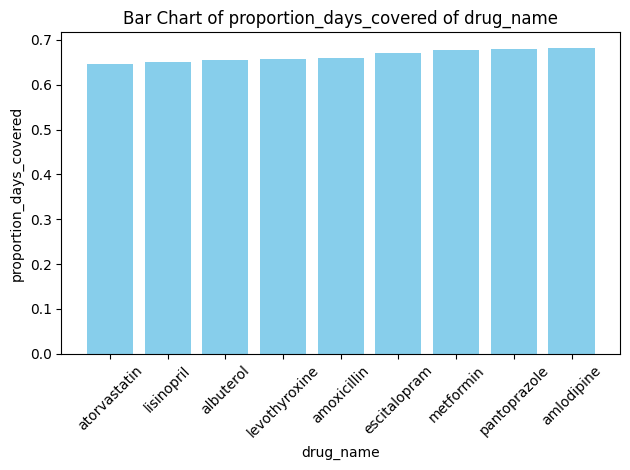

In [9]:
# Show average PDC per drug; dataset.bar() returns the Figure directly
fig = dataset.bar('drug_name', 'proportion_days_covered')
fig.tight_layout()
display(fig)
plt.close(fig)

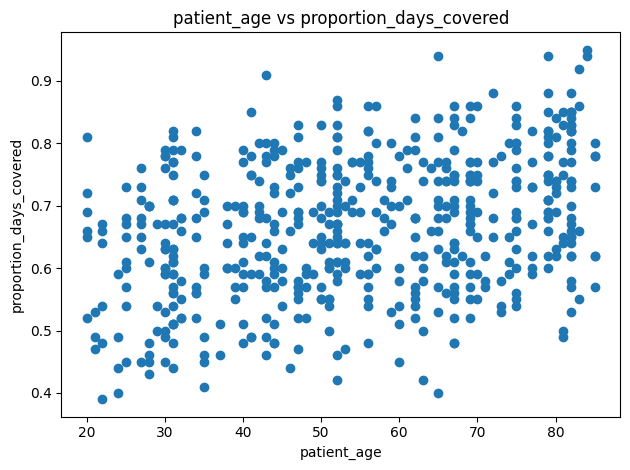

In [10]:
# Scatter patient age vs PDC; dataset.scatter() returns the Figure directly
fig = dataset.scatter('patient_age', 'proportion_days_covered')
fig.tight_layout()
display(fig)
plt.close(fig)

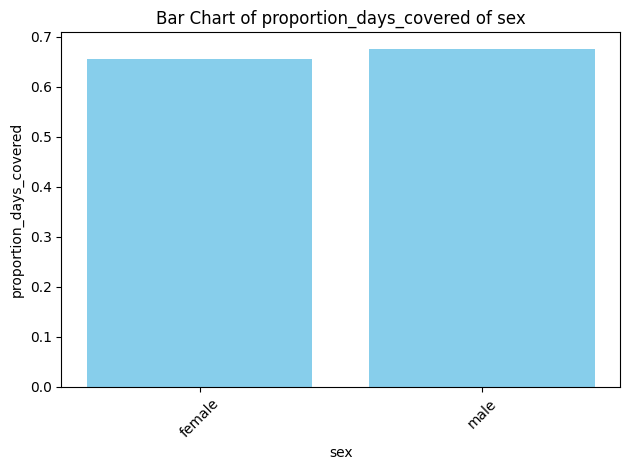

In [11]:
# Compare average PDC between male and female patients
fig = dataset.bar('sex', 'proportion_days_covered')
fig.tight_layout()
display(fig)
plt.close(fig)

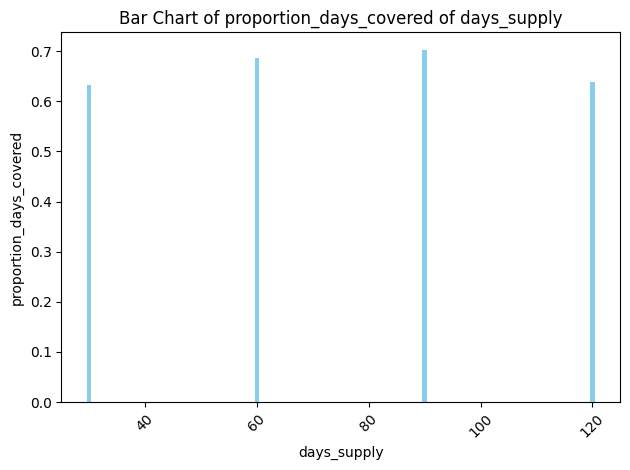

In [12]:
# Show how average PDC varies by days_supply (e.g. 30-day vs 90-day fills)
fig = dataset.bar('days_supply', 'proportion_days_covered')
fig.tight_layout()
display(fig)
plt.close(fig)

## 4. Patient Adherence Profiles

In [13]:
# Pick the first patient ID in the cleaned dataset as a demo subject
patient_id = df['patient_id'].iloc[0]
# Build a PatientAdherenceProfile for this patient to access their prescription history
patient = dataset.get_patient(patient_id)
print(f'Patient: {patient_id}') 
# Print a concise summary dict: fills, copay, days supply, PDC, and adherent flag
print(patient.summary())

Patient: P001
{'patient_id': 'P001', 'total_fills': 4, 'avg_copay': np.float64(14.469999999999999), 'avg_days_supply': np.float64(60.0), 'pdc': np.float64(0.6799999999999999), 'adherent': np.False_}


In [14]:
# Total number of prescription fills on record for this patient
print(f'Total fills:       {patient.total_fills()}')
# Mean out-of-pocket cost per fill
print(f'Avg copay:         ${patient.average_copay():.2f}')
# Mean days of medication supplied per fill
print(f'Avg days supply:   {patient.average_days_supply():.1f} days')
# Mean proportion_days_covered across all fills
print(f'PDC:               {patient.calculate_pdc():.2f}')
# Boolean: does PDC meet the standard 75% adherence threshold?
print(f'Adherent (>=0.75): {patient.is_adherent()}')
# Boolean: does PDC meet a relaxed 50% threshold?
print(f'Adherent (>=0.50): {patient.is_adherent(threshold=0.50)}')

Total fills:       4
Avg copay:         $14.47
Avg days supply:   60.0 days
PDC:               0.68
Adherent (>=0.75): False
Adherent (>=0.50): True


In [15]:
# Build summary rows for the first 10 unique patients in the dataset
summaries = [dataset.get_patient(pid).summary() for pid in df['patient_id'].unique()[:10]]
# Assemble into a DataFrame for easy comparison across patients
summary_df = pd.DataFrame(summaries)
# Round floating-point columns to 2 decimal places for readability
summary_df[['pdc', 'avg_copay']] = summary_df[['pdc', 'avg_copay']].round(2)
summary_df

,patient_id,total_fills,avg_copay,avg_days_supply,pdc,adherent
0,P001,4,14.47,60.0,0.68,False
1,P002,5,14.05,90.0,0.65,False
2,P003,2,19.90,105.0,0.52,False
3,P004,4,14.07,67.5,0.70,False
4,P005,4,10.28,90.0,0.77,True
5,P006,5,15.75,72.0,0.61,False
6,P007,2,13.00,75.0,0.60,False
7,P008,2,14.80,90.0,0.66,False
8,P009,4,21.27,97.5,0.50,False
9,P010,3,17.22,80.0,0.63,False


## 5. Linear Regression — Predicting PDC

Predict the continuous `proportion_days_covered` value from patient and prescription features.

In [16]:
# Drop rows where the target is missing so training does not fail
model_df = df.dropna(subset=['proportion_days_covered'])
# Define the feature set: two demographic and three prescription-level predictors
linear_features = ['patient_age', 'sex', 'days_supply', 'copay_amount', 'refill_number']

# Instantiate ModelTrainer with the continuous PDC target
linear_trainer = ModelTrainer(df=model_df, target='proportion_days_covered', features=linear_features)
# Train the linear regression model and retrieve the fitted pipeline and metrics
linear_model, linear_metrics = linear_trainer.train_linear()

# Print MSE, MAE, and R2 scores
for k, v in linear_metrics.items():
    print(f'{k}: {v:.4f}')

mse: 0.0033
mae: 0.0481
r2: 0.7685


**Metrics:** MSE and MAE measure average prediction error (lower is better). R2 measures how much variance the model explains (1.0 = perfect, 0 = no better than predicting the mean).

## 6. Logistic Regression — Predicting Adherence

Predict the binary `adherence_flag` (0/1) — more actionable for clinical risk stratification.

In [17]:
# Drop rows where the binary target is missing
logistic_df = df.dropna(subset=['adherence_flag']).copy()
# Cast to int so sklearn treats the target as a classification label, not a float
logistic_df['adherence_flag'] = logistic_df['adherence_flag'].astype(int)
# Use the same feature set as the linear model for a direct comparison
logistic_features = ['patient_age', 'sex', 'days_supply', 'copay_amount', 'refill_number']

# Instantiate ModelTrainer with the binary adherence target
logistic_trainer = ModelTrainer(df=logistic_df, target='adherence_flag', features=logistic_features)
# Train the logistic regression model and retrieve the fitted pipeline and metrics
logistic_model, logistic_metrics = logistic_trainer.train_logistic()

# Print accuracy, precision, recall, and ROC-AUC scores
for k, v in logistic_metrics.items():
    print(f'{k}: {v:.4f}')

accuracy: 0.8807
precision: 0.7917
recall: 0.7037
roc_auc: 0.9408


**Metrics:** Accuracy = overall correct rate. Precision = of predicted-adherent patients, how many truly are. Recall = of truly-adherent patients, how many were caught. ROC-AUC >= 0.70 is considered actionable for intervention programs.

In [18]:
# Retrieve the stored metrics dict from the trainer at any time after training
logistic_trainer.evaluate()

{'accuracy': 0.8807339449541285,
 'precision': 0.7916666666666666,
 'recall': 0.7037037037037037,
 'roc_auc': 0.9408310749774165}

## 7. Feature Exploration

In [19]:
# Define four feature sets ranging from minimal to rich to see which combination performs best
feature_sets = {
    'demographics only': ['patient_age', 'sex'],
    'prescription only': ['days_supply', 'copay_amount', 'refill_number'],
    'all basic':         ['patient_age', 'sex', 'days_supply', 'copay_amount', 'refill_number'],
    'add drug+pharmacy': ['patient_age', 'sex', 'days_supply', 'copay_amount',
                          'refill_number', 'drug_name', 'pharmacy_name'],
}

# Train a linear model for each feature set and collect MSE, MAE, and R2
linear_results = []
for label, feats in feature_sets.items():
    _, metrics = ModelTrainer(df=model_df, target='proportion_days_covered', features=feats).train_linear()
    linear_results.append({'features': label, **metrics})

print('Linear — Feature Comparison')
# Display results as a table; higher R2 and lower MAE indicate a better-fitting feature set
pd.DataFrame(linear_results).set_index('features').round(4)

Linear — Feature Comparison


,mse,mae,r2
features,,,
demographics only,0.0118,0.0900,0.1822
prescription only,0.0055,0.0607,0.6164
all basic,0.0033,0.0481,0.7685
add drug+pharmacy,0.0035,0.0500,0.7551


In [20]:
# Train a logistic model for each feature set and collect accuracy, precision, recall, ROC-AUC
logistic_results = []
for label, feats in feature_sets.items():
    _, metrics = ModelTrainer(df=logistic_df, target='adherence_flag', features=feats).train_logistic()
    logistic_results.append({'features': label, **metrics})

print('Logistic — Feature Comparison')
# Display results as a table; higher ROC-AUC indicates better ability to rank adherent vs non-adherent patients
pd.DataFrame(logistic_results).set_index('features').round(4)

Logistic — Feature Comparison


,accuracy,precision,recall,roc_auc
features,,,,
demographics only,0.7523,0.0000,0.0000,0.7726
prescription only,0.8165,0.6667,0.5185,0.8778
all basic,0.8807,0.7917,0.7037,0.9408
add drug+pharmacy,0.8807,0.7917,0.7037,0.9336


## 8. Interpretation and Domain Insights

### Which features are most predictive?

Prescription-level features consistently outperform demographics alone:

| Feature | Effect | Reason |
|---------|--------|--------|
| `days_supply` | higher → higher PDC | 90-day fills reduce refill trips and lapses |
| `copay_amount` | higher → lower PDC | cost burden is the top documented barrier to adherence |
| `refill_number` | more → higher PDC | past refill behavior predicts future behavior |
| `drug_name` | varies | chronic disease drugs have lower adherence than acute-course drugs |
| `pharmacy_name` | varies | consistent pharmacy use correlates with fewer gaps |
| `patient_age` | mild positive | older patients tend to have more established medication routines |
| `sex` | small | females show slightly higher healthcare engagement in the literature |

### Does this make sense clinically?

Yes. The findings align with pharmacoepidemiology research:

- **90-day supplies** raise adherence by 5–15 percentage points versus 30-day fills — fewer opportunities to lapse.
- **High copays** are the most actionable lever; copay assistance programs directly improve PDC.
- **Refill history** is the strongest behavioral signal — past adherence is the best predictor of future adherence.
- **Drug type** encodes disease urgency: patients stopping a blood pressure pill feel nothing immediately, unlike stopping an inhaler.
- **Demographics** are proxies for access and disease complexity, not direct causes. Interventions should focus on modifiable factors: extended supply, copay assistance, and refill reminders.